### Agentic AI Foundations with LangGraph & Tool ⭐
#### International Money Transfer Application with real-time currency exchange ⭐

---

### Recap - LANG-GRAPH-101

We built a node and edge based agentic system to calculate the return on Investment, platform fee, target currency, and static exchange rate;

### Goal of this session

Add a tool - fetch the exchange rate real-time instead of static value.

### Flow

**Scenario:** A user invested `$1,000` in F5 stock (12% ROI) and wants to transfer the proceeds abroad after paying a 2% platform fee in either EUR, or JPY. The exchange rate has to be as of now

Four specialized agents are orchestrated in this graph, Along with tool:

```
[START]
   │
   ▼
[ReturnOnInvestment]  ← calculates $1,000 × 1.12 = $1,120
   │
   ▼
[PlatformFee]         ← deducts 2% service fee → net $1,097.60
   │
   ▼
[Call to Tool for exchange rate] ⭐
   │
   ├── "JPY" ──▶  [ConvertToJPY]  ─┐
   │                               ├──▶ [END]
   └── "EUR" ──▶  [ConvertToEUR]  ─┘
```

### Step 1 — Define the State Schema

The **State** is the shared memory of the entire graph. Every agent reads from and writes to this single object — no agent needs to call another directly.

`TypedDict` enforces structure: all keys and their types are declared upfront. This prevents the most common LangGraph bug — a node writing a key that isn't in the schema gets **silently dropped** by LangGraph's merge logic, causing a `KeyError` downstream.

> **Rule of thumb:** If a node writes it, it must live in the schema.

| Field | Owner | Description |
|---|---|---|
| `amount_usd` | User (input) | Invested amount in USD |
| `roi_amount_usd` | `ReturnOnInvestment` | Value after 12% appreciation |
| `platform_fee` | `PlatformFee` | 2% service fee in USD |
| `net_roi` | `PlatformFee` | Amount after fee deduction |
| `target_currency` | User (input) | Destination currency (JPY or EUR) |
| `exchange_rate` | `FetchExchangeRate` | Exchange rate from a tool: fetch_exchange_rate() |
| `transfer_amount_in_choosen_currency` | `ConvertToJPY` / `ConvertToEUR` | Final transfer amount |

In [1]:
from typing import TypedDict, Literal

class SendMoneyRequest(TypedDict):
    amount_usd: float                              # INPUT:  User's starting amount
    roi_amount_usd: float                          # SET BY: ReturnOnInvestment
    platform_fee: float                            # SET BY: PlatformFee (fee amount in USD)
    net_roi: float                                 # SET BY: PlatformFee (amount after fee)
    target_currency: Literal['JPY', 'EUR']         # INPUT:  User's chosen destination currency
    exchange_rate: float                           # SET BY: FetchExchangeRate (live from API) ⭐
    transfer_amount_in_choosen_currency: float     # SET BY: ConvertToJPY or ConvertToEUR

### Step 2 — Define the Agents (Nodes)

Each function below is one autonomous agent — a **node** in the graph.

### Agent Contract
```
Input:  current state (SendMoneyRequest dict)
Output: updated state with its own fields populated
Rule:   each agent only touches the fields it "owns" — separation of concerns
```

This mirrors real-world agentic design: a billing agent shouldn't be doing currency math. Specialization makes agents independently testable and replaceable.

> **`FetchExchangeRate`** below is a real-world example of a **Tool node** — it calls a live REST API and injects the result into shared state for downstream agents to consume.

In [2]:
# ── AGENT 1: Investment Return ────────────────────────────────────────────────
# Responsibility: Calculate the USD value after investment appreciation.
# Reads:  amount_usd  (set by the user as initial input)
# Writes: roi_amount_usd
def return_on_investment(state: SendMoneyRequest) -> SendMoneyRequest:
    state['roi_amount_usd'] = state["amount_usd"] * 1.12   # 12% ROI: $1,000 → $1,120
    return state


# ── AGENT 2: Platform Fee ─────────────────────────────────────────────────────
# Responsibility: Deduct the transfer service fee from the appreciated amount.
# Reads:  roi_amount_usd  (written by Agent 1 — this is how agents chain together)
# Writes: platform_fee, net_roi
def platform_fee(state: SendMoneyRequest) -> SendMoneyRequest:
    state['platform_fee'] = state["roi_amount_usd"] * 0.02             # 2% fee in USD
    state['net_roi'] = state["roi_amount_usd"] - state["platform_fee"] # Amount after fee
    return state


# ── ROUTER: Conditional Edge Function (NOT a node) ───────────────────────────
# Responsibility: Inspect state and return a string key that tells LangGraph
# which node to execute next. This is the "decision point" of the agent system.
# It is passed to add_conditional_edges(), NOT add_node().
def choose_conversion(state: SendMoneyRequest) -> str:
    return state["target_currency"]   # Returns "JPY" or "EUR"


# ── AGENT 4: JPY Conversion ───────────────────────────────────────────────────
# Responsibility: Convert net USD amount to Japanese Yen.
# Only executes when choose_conversion() returns "JPY".
# Reads:  net_roi, exchange_rate  ← exchange_rate is now LIVE from FetchExchangeRate ⭐
# Writes: transfer_amount_in_choosen_currency
def convert_to_JPY(state: SendMoneyRequest) -> SendMoneyRequest:
    # Uses live rate from state — NOT a hardcoded constant
    state['transfer_amount_in_choosen_currency'] = state["net_roi"] * state["exchange_rate"]
    return state


# ── AGENT 5: EUR Conversion ───────────────────────────────────────────────────
# Responsibility: Convert net USD amount to Euros.
# Only executes when choose_conversion() returns "EUR".
# Reads:  net_roi, exchange_rate  ← exchange_rate is now LIVE from FetchExchangeRate ⭐
# Writes: transfer_amount_in_choosen_currency
def convert_to_EUR(state: SendMoneyRequest) -> SendMoneyRequest:
    # Uses live rate from state — NOT a hardcoded constant
    state['transfer_amount_in_choosen_currency'] = state["net_roi"] * state["exchange_rate"]
    return state

### 🌐 Step 2b — The Live FX Rate Tool (New Node) ⭐

#### What is a Tool in Agentic AI?

A **Tool** is a node that reaches *outside* the graph to interact with the real world — a REST API, a database, a file system, or an LLM. It is the bridge between the internal state machine and live external data.

| | Without Tool | With Tool |
|---|---|---|
| **Rate source** | `rate = 158.94` (hardcoded, stale) | `rate = fetch_exchange_rate()` (live, accurate) |
| **Accuracy** | Wrong if market moves | Always current |
| **Error handling** | Not needed | Must handle network failures gracefully |

#### API Used: [Open Exchange Rates (ER-API)](https://www.exchangerate-api.com/)

- **Free tier, no API key required**
- Updated every 24 hours
- Endpoint: `https://open.er-api.com/v6/latest/USD`
- Response: `{ "base_code": "USD", "rates": { "JPY": 157.23, "EUR": 0.92, ... } }`

#### Fallback Strategy

Network calls can fail. A robust tool node always has a **fallback** so the graph never crashes:

```
Try live API  ──▶  Success → extract rates[currency], write to state
                └─ Failure → log warning, write hardcoded fallback rate to state
```

In [3]:
import urllib.request
import json

# Fallback rates used only if the API call fails (e.g., no internet, API down)
FALLBACK_RATES = {
    "JPY": 158.94,
    "EUR": 0.86,
}

# ── TOOL NODE: Live Exchange Rate Fetcher ─────────────────────────────────────
# Responsibility: Fetch the real-time USD → target_currency exchange rate
#                 from open.er-api.com (free, no API key required).
#
# This is what makes this node a "Tool" in Agentic AI terms:
#   - It reaches OUTSIDE the graph to call a live external REST API
#   - It injects real-world data into shared state for downstream agents to use
#   - It handles errors gracefully so the graph never crashes on a network failure
#
# Reads:  target_currency  (set by the user)
# Writes: exchange_rate    (live rate, or fallback if API is unreachable) ⭐
def fetch_exchange_rate(state: SendMoneyRequest) -> SendMoneyRequest:
    currency = state["target_currency"]  # "JPY" or "EUR"
    url = f"https://open.er-api.com/v6/latest/USD"

    try:
        # ── Live API call ──────────────────────────────────────────────────────
        # Fetches all rates in one call; we extract only the currency we need.
        # timeout=5 ensures the graph doesn't hang on a slow network.
        with urllib.request.urlopen(url, timeout=5) as response:
            data = json.loads(response.read().decode())
            # Response shape: { "base_code": "USD", "rates": { "JPY": 157.23, "EUR": 0.92, ... } }
            live_rate = data["rates"][currency]
            state["exchange_rate"] = live_rate
            print(f"[FetchExchangeRate] ✅ Live rate  : 1 USD = {live_rate} {currency}  (source: open.er-api.com)")

    except Exception as e:
        # ── Graceful fallback ─────────────────────────────────────────────────
        # If the API is unreachable, use a hardcoded fallback so the graph
        # continues without interruption — resilience is a core design principle
        # of production-grade agentic systems.
        fallback = FALLBACK_RATES[currency]
        state["exchange_rate"] = fallback
        print(f"[FetchExchangeRate] ⚠️  API error  : {e}")
        print(f"[FetchExchangeRate] ⚠️  Fallback   : 1 USD = {fallback} {currency}")

    return state

### Step 3 — Build and Compile the Graph

This is where LangGraph wires everything together — drawing the flowchart that defines who runs, when, and under what conditions.

The only structural change from a basic graph: `FetchExchangeRate` is inserted between `PlatformFee` and the conditional branch, so the live rate is guaranteed to be in state before routing happens.

### Key API calls

| Method | Purpose |
|---|---|
| `StateGraph(Schema)` | Creates a graph backed by the given state schema |
| `add_node(name, fn)` | Registers an agent function under a string identifier |
| `add_edge(A, B)` | Fixed transition: A always leads to B |
| `add_conditional_edges(src, router, map)` | Dynamic transition: router inspects state and returns a key; map resolves key → next node |
| `compile()` | Validates the graph and returns a `Runnable` ready to execute |

In [4]:
from langgraph.graph import StateGraph, START, END

# StateGraph takes the schema so it knows the shape of shared memory
builder = StateGraph(SendMoneyRequest)

# -- Register nodes (agents) --------------------------------------------------
builder.add_node("ReturnOnInvestment", return_on_investment)
builder.add_node("PlatformFee", platform_fee)
builder.add_node("FetchExchangeRate", fetch_exchange_rate)  # ⭐ New tool node
builder.add_node("ConvertToJPY", convert_to_JPY)
builder.add_node("ConvertToEUR", convert_to_EUR)

# -- Fixed edges: deterministic, always A → B ---------------------------------
builder.add_edge(START, "ReturnOnInvestment")           # Entry point
builder.add_edge("ReturnOnInvestment", "PlatformFee")   # Always deduct fee after ROI
builder.add_edge("PlatformFee", "FetchExchangeRate")    # ⭐ Fee → fetch live rate

# -- Conditional edge: intelligent routing AFTER live rate is in state --------
# choose_conversion() now runs after FetchExchangeRate, so the live rate
# is guaranteed to be in state before we branch to the conversion agents.
builder.add_conditional_edges(
    "FetchExchangeRate",   # ⭐ Branch FROM FetchExchangeRate (not PlatformFee)
    choose_conversion,     # Router: called with current state, returns branch key
    {                      # Map: return value → target node
        "JPY": "ConvertToJPY",
        "EUR": "ConvertToEUR",
    }
)

# Both conversion branches converge to END (multi-source edge)
builder.add_edge(["ConvertToJPY", "ConvertToEUR"], END)

# compile() validates the graph structure and returns an executable Runnable
graph = builder.compile()

### Step 4 — Visualize the Graph

LangGraph can render the graph topology as a **Mermaid diagram** so you can visually confirm the agent wiring matches your design before running it.

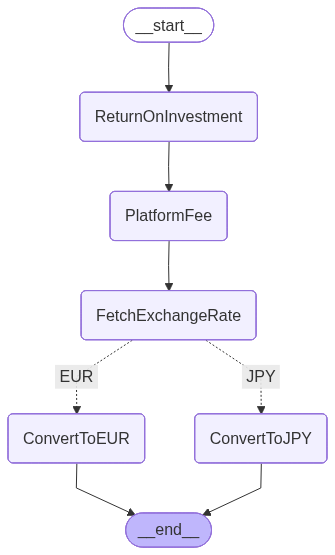

In [5]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

### Step 5 — Invoke the Graph

`graph.invoke()` is the entry point. It:
1. Takes the initial state dict (only user-provided fields)
2. Feeds it into `START`, then propagates through the graph
3. Each agent updates state; LangGraph merges updates back automatically
4. Returns the final state after `END` is reached

> **Important:** Only supply the fields your first agent needs to *read*. Fields written by agents (`roi_amount_usd`, `platform_fee`, `net_roi`, `transfer_amount_in_choosen_currency`) will be populated by the graph — passing pre-set values for them in the initial input could interfere with results.


In [6]:
graph.invoke({
    "amount_usd": 1000.0,       # User's starting investment amount
    "target_currency": "EUR"    # User's chosen destination currency
})

[FetchExchangeRate] ✅ Live rate  : 1 USD = 0.860568 EUR  (source: open.er-api.com)


{'amount_usd': 1000.0,
 'roi_amount_usd': 1120.0,
 'platform_fee': 22.400000000000002,
 'net_roi': 1097.6,
 'target_currency': 'EUR',
 'exchange_rate': 0.860568,
 'transfer_amount_in_choosen_currency': 944.5594368}

### Summary — Agentic AI Concepts in This App

| Concept | How it appears in this app |
|---|---|
| **Specialized agents** | One node per concern: ROI / Fee / open.er-api.com Tool / Currency conversion |
| **Shared state** | `SendMoneyRequest` dict flows through all agents unchanged |
| **Tool use** | `FetchExchangeRate` calls a live REST API and injects the result into state ⭐ |
| **Graceful fallback** | Tool catches network errors and uses a safe default — graph never crashes |
| **Autonomous routing** | `choose_conversion()` decides the JPY vs EUR path at runtime |
| **Graph topology** | Linear flow → tool call → conditional fan-out at `FetchExchangeRate` |
| **Composability** | Swap the API URL, add currencies, or use a paid FX service — zero changes elsewhere |

### Tool Node Design Principles

```
1. Single responsibility — fetch one thing, write one field to state
2. Always handle errors  — never let a network failure crash the graph
3. Log clearly           — print what rate was used (live or fallback)
4. Set a timeout         — always pass timeout= to HTTP calls to avoid hanging
5. Declare in schema     — the field written (exchange_rate) must be in TypedDict
```